# Steering methods across depth and tasks — oracle sweep analysis

Compares the shared-autonomy arms on the runs written by
[`oracle_sweep.sh`](../oracle_sweep.sh) (or any set of `experiment.py` runs) into
`outputs/pi05_libero_oracle_sweep/`. Each run is one *block*: a method
(FC = shared flow control, FRS = native flow reversal steering, FRS+F = flow
reversal with the reversal adapter) at one *depth* (the number of denoising
steps the operator controls: `n_guided_steps` for FC, `n_reversal_steps` for the
reversal arms) on one task, plus two policy-only anchors per task (the arm's
uninformative prompt = floor, the scene's real instruction = ceiling).

The helpers live in [`analyze.py`](analyze.py); the point of this
notebook is the **performance-vs-controlled-steps figure** with one line per method.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

for candidate in (Path.cwd(), Path.cwd() / "examples/pi05/libero_shared_autonomy/notebooks"):
    if (candidate / "analyze.py").exists():
        sys.path.insert(0, str(candidate))
        REPO_ROOT = candidate.parents[3] if candidate.name == "notebooks" else Path.cwd()
        break
import analyze  # noqa: E402

ROOT = REPO_ROOT / "outputs/pi05_libero_oracle_sweep"  # point elsewhere to compare other runs
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

/home/user/Projects/lerobot/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load

Every trial gets `method`, `depth`, `task_id` and `mode_expressed` (the scene
element that moved most during the trial). `operator` says who drove: `policy`
for the oracle sweep, `human` for SpaceMouse sessions — keep them apart when
both are present.

In [2]:
trials, configs = analyze.load_runs(analyze.find_runs(ROOT))
print(
    f"{len(trials)} trials, {trials['run'].nunique()} runs, {trials['task_id'].nunique()} tasks, "
    f"operators: {sorted(trials['operator'].unique())}"
)
trials.groupby(["method", "depth"], dropna=False).size().unstack(fill_value=0)

1700 trials, 170 runs, 10 tasks, operators: ['policy']


depth,2.0,4.0,6.0,8.0,10.0,NaN
method,,,,,,
FC,100,100,100,100,100,0
FRS,100,100,100,100,100,0
FRS+F,100,100,100,100,100,0
policy (ceiling),0,0,0,0,0,100
policy (floor),0,0,0,0,0,100


## Success rate vs. controlled steps

The figure asked for: x = denoising steps the operator controls, y = success rate
pooled over tasks, one line per method with Wilson 95% intervals. The anchors
are dashed horizontal lines (floor: the policy alone with the uninformative
prompt; ceiling: the policy alone with the real instruction).

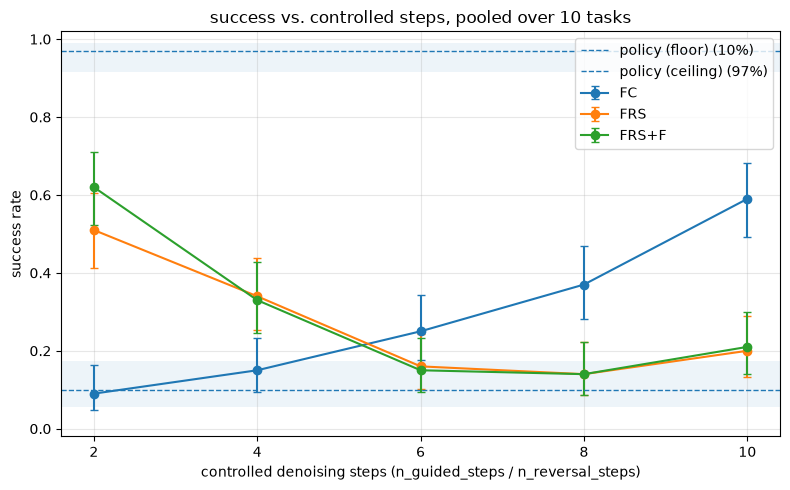

,method,depth,trials,successes,rate,ci95_low,ci95_high
0,FC,2.0,100,9,0.09,0.048072,0.162264
1,FC,4.0,100,15,0.15,0.093059,0.232837
2,FC,6.0,100,25,0.25,0.175451,0.343046
3,FC,8.0,100,37,0.37,0.281822,0.467797
4,FC,10.0,100,59,0.59,0.492013,0.681328
5,FRS,2.0,100,51,0.51,0.413478,0.605782
6,FRS,4.0,100,34,0.34,0.254614,0.437225
7,FRS,6.0,100,16,0.16,0.100952,0.244204
8,FRS,8.0,100,14,0.14,0.085263,0.221374
9,FRS,10.0,100,20,0.20,0.133366,0.288831


In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
curve = analyze.plot_performance_vs_depth(trials, ax, metric="success")
plt.tight_layout()
plt.show()
curve

## Did the steering select the right behaviour?

Success is two-stage in the intent-agnostic setting: the steering must first
select the intended mode of the policy's prior, then the policy must execute
it. `on_target` is whether the trial's most-moved scene element is the task's
own (taken from what the ceiling anchor moves when it succeeds), regardless of
whether the trial finished. This separates *wrong mode* from *right mode, not
finished*.

task targets (from the ceiling anchor):
  task 0: wooden_cabinet_1_middle_level            open the middle drawer of the cabinet
  task 1: akita_black_bowl_1                       put the bowl on the stove
  task 2: wine_bottle_1                            put the wine bottle on top of the cabinet
  task 3: akita_black_bowl_1                       open the top drawer and put the bowl inside
  task 4: akita_black_bowl_1                       put the bowl on top of the cabinet
  task 5: plate_1                                  push the plate to the front of the stove
  task 6: cream_cheese_1                           put the cream cheese in the bowl
  task 7: flat_stove_1_button                      turn on the stove
  task 8: akita_black_bowl_1                       put the bowl on the plate
  task 9: wine_bottle_1                            put the wine bottle on the rack


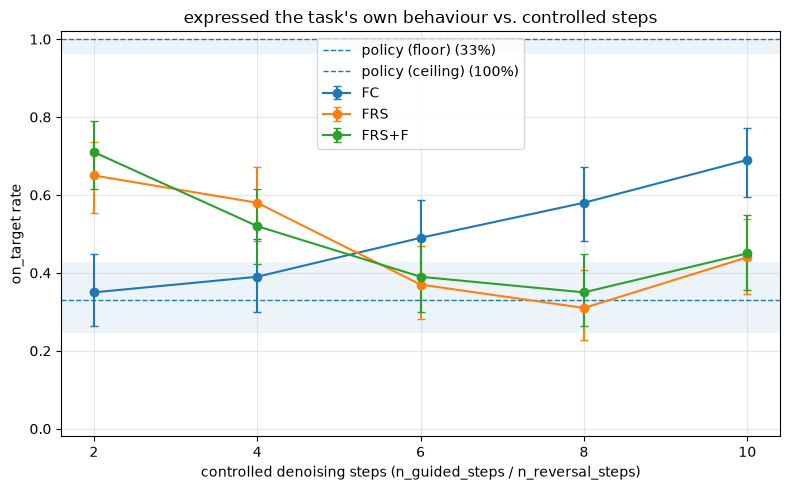

In [4]:
tagged = analyze.with_mode_accuracy(trials)
print("task targets (from the ceiling anchor):")
for task_id, target in sorted(analyze.task_targets(trials).items()):
    desc = trials.loc[trials["task_id"] == task_id, "task_description"].iloc[0]
    print(f"  task {task_id}: {target!s:40s} {desc}")

fig, ax = plt.subplots(figsize=(8, 5))
analyze.plot_performance_vs_depth(
    tagged, ax, metric="on_target", title="expressed the task's own behaviour vs. controlled steps"
)
plt.tight_layout()
plt.show()

## Both metrics side by side, and the best depth per method

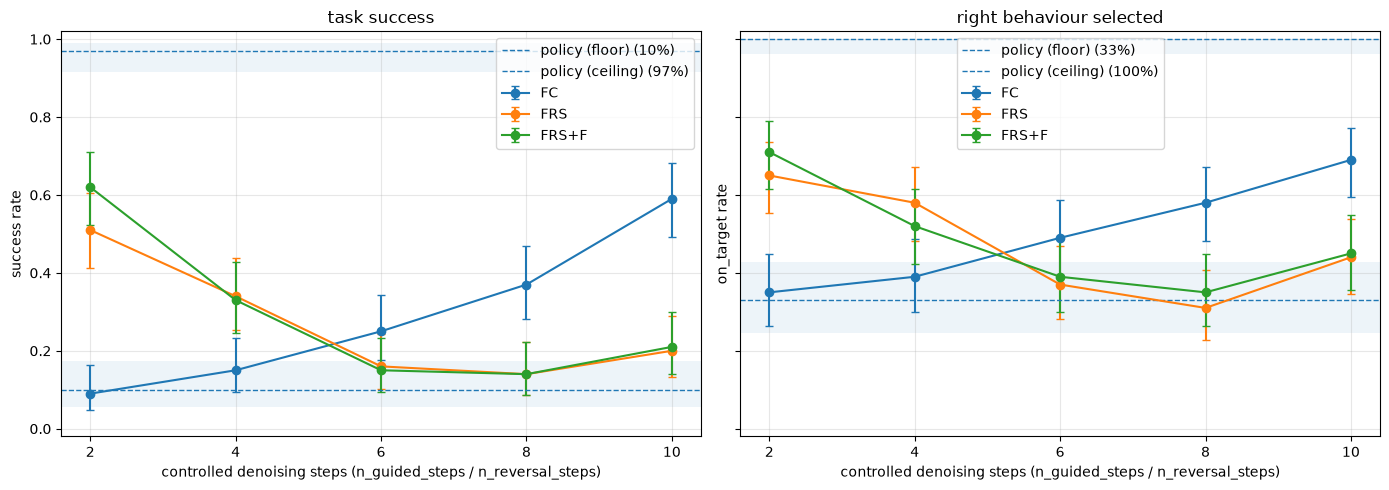

,method,depth,trials,successes,rate,ci95_low,ci95_high
0,FC,10.0,100,59,0.59,0.492013,0.681328
1,FRS,2.0,100,51,0.51,0.413478,0.605782
2,FRS+F,2.0,100,62,0.62,0.522096,0.709026


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
analyze.plot_performance_vs_depth(tagged, axes[0], metric="success", title="task success")
analyze.plot_performance_vs_depth(tagged, axes[1], metric="on_target", title="right behaviour selected")
plt.tight_layout()
plt.show()
analyze.best_depth(tagged, "success")

## Per task

Rows = task, columns = (method, depth). Tasks where every arm is at the floor
are not informative for comparing methods; tasks with a gradient are the ones
to take to human trials.

In [6]:
per_task = analyze.per_task_table(tagged, "success")
per_task.style.format("{:.0%}", na_rep="–").background_gradient(cmap="Blues", vmin=0, vmax=1)

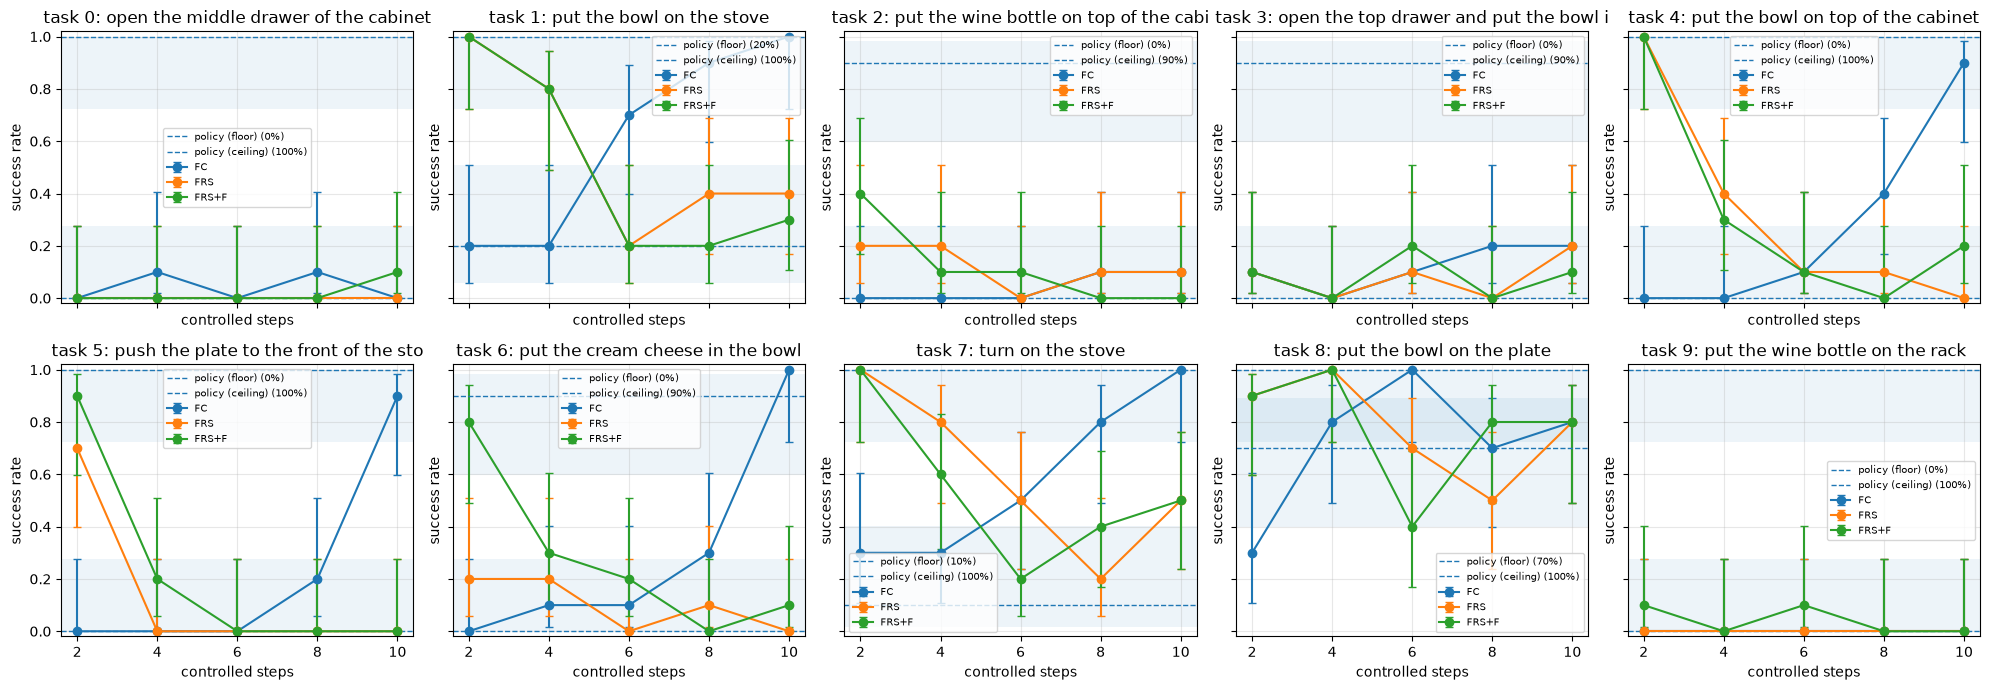

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7), sharex=True, sharey=True)
for ax, (task_id, group) in zip(axes.ravel(), tagged.groupby("task_id"), strict=False):
    desc = group["task_description"].iloc[0]
    analyze.plot_performance_vs_depth(group, ax, metric="success", title=f"task {task_id}: {desc[:38]}")
    ax.legend(fontsize=7)
    ax.set_xlabel("controlled steps")
plt.tight_layout()
plt.show()

## How much of the intent got through

From the per-step arrays: the cosine between the executed translation and the
operator's *raw* command (the clean intent, before the corruption) versus the
*served* command (what the policy was given). A method that undoes the
corruption has `cos_raw` above `cos_served`; a method that just follows the
corrupted command has the opposite. This is a continuous measure, independent
of task success, so it stays informative even where success is at the floor.

In [8]:
steered = tagged[tagged["method"].isin(["FC", "FRS", "FRS+F"])]
transmission = analyze.step_metrics(steered)
summary = (
    transmission.groupby(["method", "depth"])[["cos_raw", "cos_served", "commanding_frac"]].mean().round(3)
)
summary

cos_raw  cos_served  commanding_frac
method depth                                      
FC     2.0      0.651       0.644            0.913
       4.0      0.683       0.682            0.959
       6.0      0.767       0.765            0.922
       8.0      0.882       0.884            0.959
       10.0     0.960       0.975            0.978
FRS    2.0      0.923       0.937            0.969
       4.0      0.793       0.799            0.964
       6.0      0.671       0.678            0.925
       8.0      0.611       0.611            0.938
       10.0     0.676       0.677            0.921
FRS+F  2.0      0.937       0.943            0.991
       4.0      0.802       0.807            0.952
       6.0      0.691       0.694            0.939
       8.0      0.613       0.614            0.925
       10.0     0.687       0.696            0.946

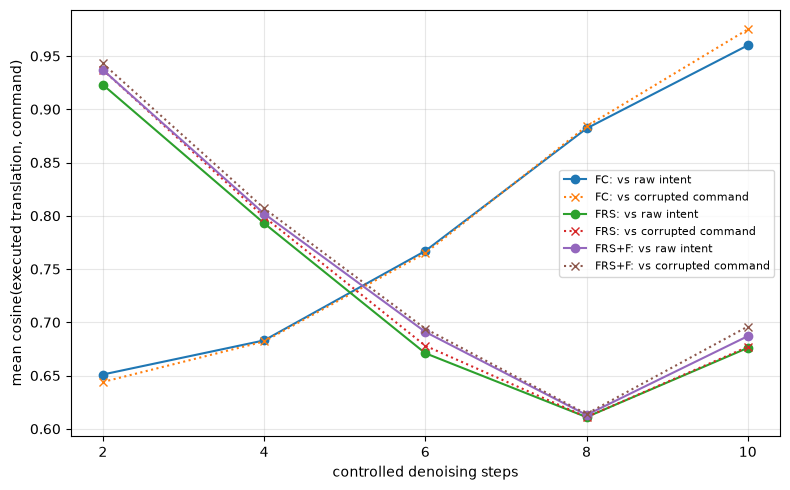

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
for method, group in summary.reset_index().groupby("method", sort=False):
    ax.plot(group["depth"], group["cos_raw"], marker="o", label=f"{method}: vs raw intent")
    ax.plot(
        group["depth"],
        group["cos_served"],
        marker="x",
        linestyle=":",
        label=f"{method}: vs corrupted command",
    )
ax.set_xlabel("controlled denoising steps")
ax.set_ylabel("mean cosine(executed translation, command)")
ax.set_xticks(sorted(summary.reset_index()["depth"].unique()))
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Paired comparison at a chosen depth

Blocks on the same task share the seed, so trial *i* is the same scene reset
across methods: McNemar's exact test on the discordant pairs, pooled over
tasks, is the right test for "does the adapter help".

In [10]:
depths = sorted(tagged["depth"].dropna().unique())
at = lambda d: tagged[tagged["depth"] == d]  # noqa: E731
pd.DataFrame(
    [
        {"depth": d, **analyze.paired_test(at(d), "method", "FRS", "FRS+F", ["task_id", "trial"])}
        for d in depths
    ]
    + [
        {"depth": d, **analyze.paired_test(at(d), "method", "FC", "FRS+F", ["task_id", "trial"])}
        for d in depths
    ]
)

,depth,A,B,paired_trials,A_rate,B_rate,A_only,B_only,discordant,mcnemar_p
0,2.0,FRS,FRS+F,100,0.51,0.62,4,15,19,1.921082e-02
1,4.0,FRS,FRS+F,100,0.34,0.33,10,9,19,1.000000e+00
2,6.0,FRS,FRS+F,100,0.16,0.15,11,10,21,1.000000e+00
3,8.0,FRS,FRS+F,100,0.14,0.14,8,8,16,1.000000e+00
4,10.0,FRS,FRS+F,100,0.20,0.21,7,8,15,1.000000e+00
5,2.0,FC,FRS+F,100,0.09,0.62,2,55,57,2.295386e-14
6,4.0,FC,FRS+F,100,0.15,0.33,3,21,24,2.771616e-04
7,6.0,FC,FRS+F,100,0.25,0.15,18,8,26,7.551870e-02
8,8.0,FC,FRS+F,100,0.37,0.14,27,4,31,3.395323e-05
9,10.0,FC,FRS+F,100,0.59,0.21,42,4,46,5.100190e-09
